In [1]:
"""
Leaky-Integrate-and-Fire model
@author: Guangyu Robert Yang @ 2017/4

"""
from __future__ import division
from collections import OrderedDict
import random as pyrand # Import before Brian floods the namespace

# Once your code is working, turn units off for speed
# import brian_no_units

from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

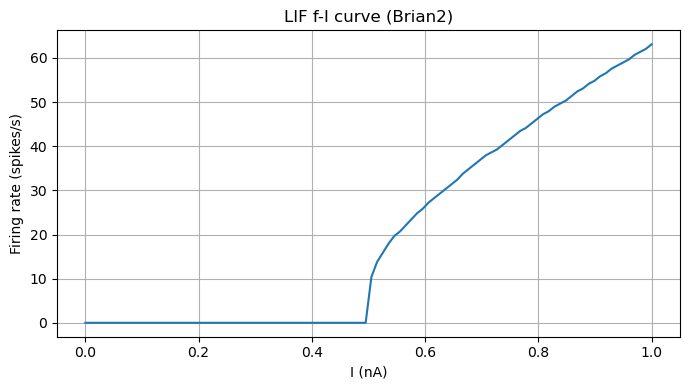

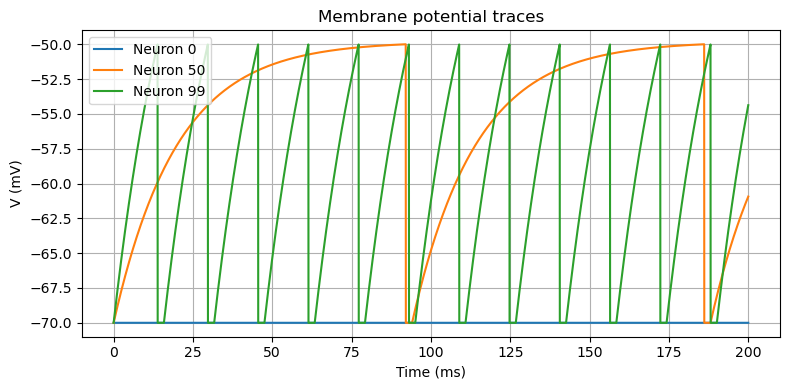

In [3]:



class LIFModel:
    """
    Simple LIF model in Brian2 for computing an f-I curve.
    """

    def __init__(self, n_neuron=100, dt=0.02*ms):
        # Clear previous Brian objects (important in notebooks)
        start_scope()
        defaultclock.dt = dt

        # Store settings
        self.n_neuron = n_neuron
        self.dt = dt

        # Model parameters
        self.V_L = -70 * mV
        self.Vth = -50 * mV
        self.Vreset = -70 * mV
        self.tau_m = 20 * ms
        self.tau_ref = 2 * ms
        self.g = 25 * nS

        # Equations
        # All parameters used in equations/threshold/reset are declared explicitly
        self.eqs = '''
        dV/dt = (-(V - V_L) + I/g) / tau_m : volt (unless refractory)
        I : amp
        g : siemens
        V_L : volt
        Vth : volt
        Vreset : volt
        tau_m : second
        '''

        # Create neuron group
        self.neurons = NeuronGroup(
            self.n_neuron,
            model=self.eqs,
            threshold='V > Vth',
            reset='V = Vreset',
            refractory=self.tau_ref,
            method='euler'
        )

        # Initialize state variables
        self.neurons.V = self.V_L
        self.neurons.I = 0 * nA

        # Set model parameters on all neurons
        self.neurons.g = self.g
        self.neurons.V_L = self.V_L
        self.neurons.Vth = self.Vth
        self.neurons.Vreset = self.Vreset
        self.neurons.tau_m = self.tau_m

        # Monitors
        self.spikemon = SpikeMonitor(self.neurons)

        # Record only a few neurons to save memory
        record_ids = [0, self.n_neuron // 2, self.n_neuron - 1]
        self.statemon = StateMonitor(self.neurons, 'V', record=record_ids)

        # Build network
        self.net = Network(self.neurons, self.spikemon, self.statemon)

    def set_current_ramp(self, I_max=1.0 * nA):
        """
        Set input currents linearly from 0 to I_max across neurons.
        """
        self.neurons.I = np.linspace(0, float(I_max / nA), self.n_neuron) * nA

    def run(self, T=3 * second):
        """
        Run the simulation for time T.
        """
        self.net.run(T)

    def firing_rates(self, T, t_ignore=100 * ms):
        """
        Compute firing rate for each neuron after ignoring an initial transient.
        """
        rates = np.zeros(self.n_neuron)

        spike_i = np.array(self.spikemon.i)
        spike_t = np.array(self.spikemon.t / second)
        t_ignore_s = float(t_ignore / second)
        effective_time = float((T - t_ignore) / second)

        for i in range(self.n_neuron):
            neuron_spike_times = spike_t[spike_i == i]
            rates[i] = np.sum(neuron_spike_times > t_ignore_s) / effective_time

        return rates

    def plot_voltage_traces(self):
        """
        Plot membrane potential traces for a few recorded neurons.
        """
        plt.figure(figsize=(8, 4))
        t=self.statemon.t/ms
        mask= t <200

        for idx in range(len(self.statemon.record)):

            plt.plot(
                t[mask],
                self.statemon.V[idx][mask] / mV,
                label=f'Neuron {self.statemon.record[idx]}')
        plt.xlabel('Time (ms)')
        plt.ylabel('V (mV)')
        plt.title('Membrane potential traces')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


def main():
    T = 3 * second
    n = 100

    # Create and run model
    model = LIFModel(n_neuron=n, dt=0.02 * ms)
    model.set_current_ramp(I_max=1.0 * nA)
    model.run(T)

    # Compute firing rates
    rates = model.firing_rates(T, t_ignore=100 * ms)

    # Plot f-I curve
    plt.figure(figsize=(7, 4))
    plt.plot(model.neurons.I / nA, rates)
    plt.xlabel("I (nA)")
    plt.ylabel("Firing rate (spikes/s)")
    plt.title("LIF f-I curve (Brian2)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Optional: plot voltage traces
    model.plot_voltage_traces()


if __name__ == "__main__":
    main()